In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import os

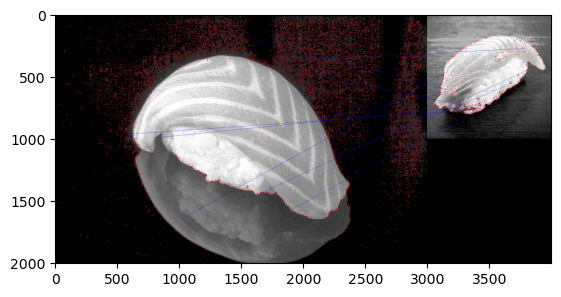

In [8]:
PATH = 'Dataset/'
object = cv2.imread(PATH + 'Object.jpg')
object = cv2.cvtColor(object, cv2.COLOR_BGR2RGB)

DATA_PATH = PATH + 'Data/'
data = []
for image_path in os.listdir(DATA_PATH):
    image_path = DATA_PATH + image_path
    image_data = cv2.imread(image_path)
    data.append(image_data)
    
# Normalization
grayscale_object = cv2.cvtColor(object, cv2.COLOR_RGB2GRAY)
grayscale_object = cv2.medianBlur(grayscale_object, 3)
grayscale_object = cv2.equalizeHist(grayscale_object)

sift = cv2.SIFT_create()
orb = cv2.ORB_create()
akaze = cv2.AKAZE_create()

target_keypoint, target_desc = akaze.detectAndCompute(grayscale_object, None)
target_desc = np.float32(target_desc)

index_param = dict(algorithm=1)
search_param = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_param, search_param)
best_match = 0

for idx, img in enumerate(data):
    # Preprocessing
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img = cv2.medianBlur(img, 3)
    img = cv2.equalizeHist(img)
    
    # Extract features
    img_keypoint, img_desc = akaze.detectAndCompute(img, None)
    img_desc = np.float32(img_desc)

    match = flann.knnMatch(target_desc, img_desc, 2)
    matches_mask = [[0,0] for _ in range(len(match))]
    current_match = 0

    for i, (fm, sm) in enumerate(match):
        # cuma bakal ambil first match kalo selisihnya jauh dari second match
        if fm.distance < 0.7 * sm.distance:
            matches_mask[i] = [1, 0]
            current_match += 1
            
    if best_match < current_match:
        best_match = current_match
        best_match_data = {
            'image_data': img,
            'keypoint': img_keypoint,
            'description': img_desc,
            'match': match,
            'matchesMask': matches_mask,
        }
        
result = cv2.drawMatchesKnn(
    grayscale_object,
    target_keypoint,
    best_match_data['image_data'],
    best_match_data['keypoint'],
    best_match_data['match'],
    None,
    matchesMask=best_match_data['matchesMask'],
    matchColor=[0,0,255],
    singlePointColor=[255,0,0]
)

plt.figure()
plt.imshow(result)
plt.show()